In [1]:
! pip install -r requirements.txt

   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
    --------------------------------------- 1.0/72.0 MB 4.6 MB/s eta 0:00:16
    --------------------------------------- 1.6/72.0 MB 3.2 MB/s eta 0:00:22
   -- ------------------------------------- 5.0/72.0 MB 7.5 MB/s eta 0:00:09
   ---- ----------------------------------- 7.6/72.0 MB 8.9 MB/s eta 0:00:08
   ----- ---------------------------------- 10.7/72.0 MB 10.2 MB/s eta 0:00:07
   ------- -------------------------------- 13.4/72.0 MB 10.8 MB/s eta 0:00:06
   --------- ------------------------------ 16.5/72.0 MB 11.2 MB/s eta 0:00:05
   ----------- ---------------------------- 20.2/72.0 MB 12.0 MB/s eta 0:00:05
   ------------- -------------------------- 23.6/72.0 MB 12.4 MB/s eta 0:00:04
   -------------- ------------------------- 26.5/72.0 MB 12.6 MB/s eta 0:00:04
   ---------------- ----------------------- 29.6/72.0 MB 12.9 MB/s eta 0:00:04
   ------------------ --------------------- 32.5/72.0 MB 13.0 MB/s et

### Importation des bibliothèques

In [2]:
import numpy as np 
import pandas as pd
from ucimlrepo import fetch_ucirepo
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score
)


### Importation de la base

In [3]:
  
# fetch dataset 
cdc_diabetes_health_indicators = fetch_ucirepo(id=891) 
  
# data (as pandas dataframes) 
X = cdc_diabetes_health_indicators.data.features  ## Il s'agit de tous les features de la base
y = cdc_diabetes_health_indicators.data.targets   ## Il s'agit de la variable cible (avoir le diabète ou pas)
  

### Visualisation des metadonnées

In [4]:
pd.set_option("display.max_colwidth", None)
vars_meta = cdc_diabetes_health_indicators.variables
vars_meta[["name", "type", "description"]]

,name,type,description
0,ID,Integer,Patient ID
1,Diabetes_binary,Binary,0 = no diabetes 1 = prediabetes or diabetes
2,HighBP,Binary,0 = no high BP 1 = high BP
3,HighChol,Binary,0 = no high cholesterol 1 = high cholesterol
4,CholCheck,Binary,0 = no cholesterol check in 5 years 1 = yes cholesterol check in 5 years
5,BMI,Integer,Body Mass Index
6,Smoker,Binary,Have you smoked at least 100 cigarettes in your entire life? [Note: 5 packs = 100 cigarettes] 0 = no 1 = yes
7,Stroke,Binary,(Ever told) you had a stroke. 0 = no 1 = yes
8,HeartDiseaseorAttack,Binary,coronary heart disease (CHD) or myocardial infarction (MI) 0 = no 1 = yes
9,PhysActivity,Binary,physical activity in past 30 days - not including job 0 = no 1 = yes


##  Exploration de la base de données

In [43]:
X.head()

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,1,1,1,40,1,0,0,0,0,1,...,1,0,5,18,15,1,0,9,4,3
1,0,0,0,25,1,0,0,1,0,0,...,0,1,3,0,0,0,0,7,6,1
2,1,1,1,28,0,0,0,0,1,0,...,1,1,5,30,30,1,0,9,4,8
3,1,0,1,27,0,0,0,1,1,1,...,1,0,2,0,0,0,0,11,3,6
4,1,1,1,24,0,0,0,1,1,1,...,1,0,2,3,0,0,0,11,5,4


In [44]:
y.describe()

,Diabetes_binary
count,253680.000000
mean,0.139333
std,0.346294
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


In [45]:
# Ajout de la cible y à X et creation de la base df
df = X.copy()
df['Diabetes_binary'] = y['Diabetes_binary'].values
df.head()

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
0,1,1,1,40,1,0,0,0,0,1,...,0,5,18,15,1,0,9,4,3,0
1,0,0,0,25,1,0,0,1,0,0,...,1,3,0,0,0,0,7,6,1,0
2,1,1,1,28,0,0,0,0,1,0,...,1,5,30,30,1,0,9,4,8,0
3,1,0,1,27,0,0,0,1,1,1,...,0,2,0,0,0,0,11,3,6,0
4,1,1,1,24,0,0,0,1,1,1,...,0,2,3,0,0,0,11,5,4,0


In [46]:
df.describe()

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,0.811420,...,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875,0.139333
std,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,0.391175,...,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148,0.346294
min,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,...,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000,0.000000
50%,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,...,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000,0.000000
75%,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,...,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000,0.000000
max,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000,1.000000


In [47]:
df.shape


(253680, 22)

La base contient 253680 observations dont 22 colonnes (y compris la cible).

In [48]:
df["Diabetes_binary"].value_counts()


Diabetes_binary
0    218334
1     35346
Name: count, dtype: int64

In [49]:
df["Diabetes_binary"].value_counts(normalize=True) * 100


Diabetes_binary
0    86.066698
1    13.933302
Name: proportion, dtype: float64

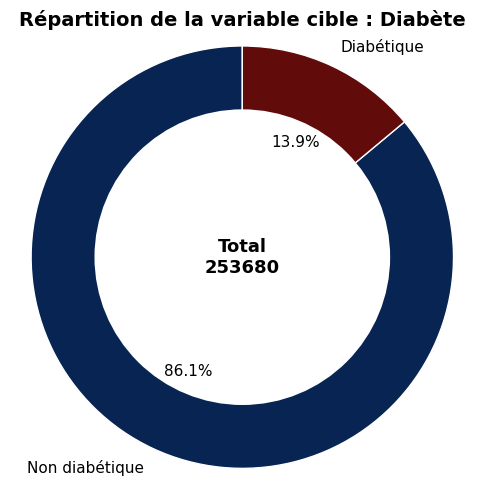

In [50]:
# Visualisation de la répartition de la variable cible 
counts = y.value_counts().sort_index()
labels = ["Non diabétique", "Diabétique"]

# Couleurs sobres et élégantes
colors = ["#072452", "#610B0B"]  # bleu / orange doux

fig, ax = plt.subplots(figsize=(5, 5))

wedges, texts, autotexts = ax.pie(
    counts.values,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    wedgeprops=dict(width=0.4, edgecolor="white"),
    textprops=dict(color="black", fontsize=11)
)

# Cercle blanc au centre (donut propre)
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
ax.add_artist(centre_circle)

# Texte central
ax.text(
    0, 0,
    f"Total\n{counts.sum()}",
    ha='center',
    va='center',
    fontsize=13,
    fontweight='bold'
)

ax.set_title(
    "Répartition de la variable cible : Diabète",
    fontsize=14,
    fontweight='bold'
)

ax.axis('equal')

plt.tight_layout()
plt.savefig(
    "repartition_variable_cible_donut_clean.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


La répartition des modalités de la variable cible est très déséquilibrée. Seulement 14% des individus sont diabétiques pour 86% qui ne le sont pas. Nous verrons plus loin comment nous exploitons les données pour faire face à cela.

In [51]:
df.isna().sum()

HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
Diabetes_binary         0
dtype: int64

Aucune valeur manquante détectée

In [52]:
np.isinf(df).sum()

HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
Diabetes_binary         0
dtype: int64

In [53]:
df.duplicated().sum()

np.int64(24206)

On a là 24206 doublons. A priori il s'agt d'observations dupliquées correspondant à des individus distincts. Elles seront donc conservées afin de préserver la distribution empirique des données et d’éviter l’introduction d’un biais artificiel.

In [54]:
## Quelques doublons

df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist())


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
4517,0,0,0,17,0,0,0,1,1,1,...,0,1,0,0,0,0,8,6,8,0
207307,0,0,0,17,0,0,0,1,1,1,...,0,1,0,0,0,0,8,6,8,0
42369,0,0,0,18,0,0,0,1,1,1,...,0,1,0,0,0,0,10,6,8,0
108949,0,0,0,18,0,0,0,1,1,1,...,0,1,0,0,0,0,10,6,8,0
17475,0,0,0,19,0,0,0,1,1,1,...,0,1,0,0,0,0,4,6,8,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
246364,1,1,1,40,0,0,0,1,1,1,...,0,2,0,0,0,0,9,6,7,0
99426,1,1,1,40,0,0,0,1,1,1,...,0,3,0,0,0,0,9,6,7,0
157792,1,1,1,40,0,0,0,1,1,1,...,0,3,0,0,0,0,9,6,7,0
41565,1,1,1,43,0,0,0,1,0,1,...,0,3,0,0,0,0,8,6,8,0


### Modalités de chaque variable 

In [55]:
for col in df.columns:
    print(col, ":", sorted(df[col].dropna().unique()))


HighBP : [np.int64(0), np.int64(1)]
HighChol : [np.int64(0), np.int64(1)]
CholCheck : [np.int64(0), np.int64(1)]
BMI : [np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52), np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(57), np.int64(58), np.int64(59), np.int64(60), np.int64(61), np.int64(62), np.int64(63), np.int64(64), np.int64(65), np.int64(66), np.int64(67), np.int64(68), np.int64(69), np.int64(70), np.int64(71), np.int64(72), np.int64(73), np.int64(74)

Les variables sont toutes numériques. Certaines variables multimodales comme education, age, income sont ordonnées. Donc nous avons jugé qu'il n'y a pas de raison de les diviser avec le One-hot incoder. 

In [56]:
binary = [
    "HighBP",
    "HighChol",
    "CholCheck",
    "Smoker",
    "Stroke",
    "HeartDiseaseorAttack",
    "PhysActivity",
    "Fruits",
    "Veggies",
    "HvyAlcoholConsump",
    "AnyHealthcare",
    "NoDocbcCost",
    "DiffWalk",
    "Sex"
]

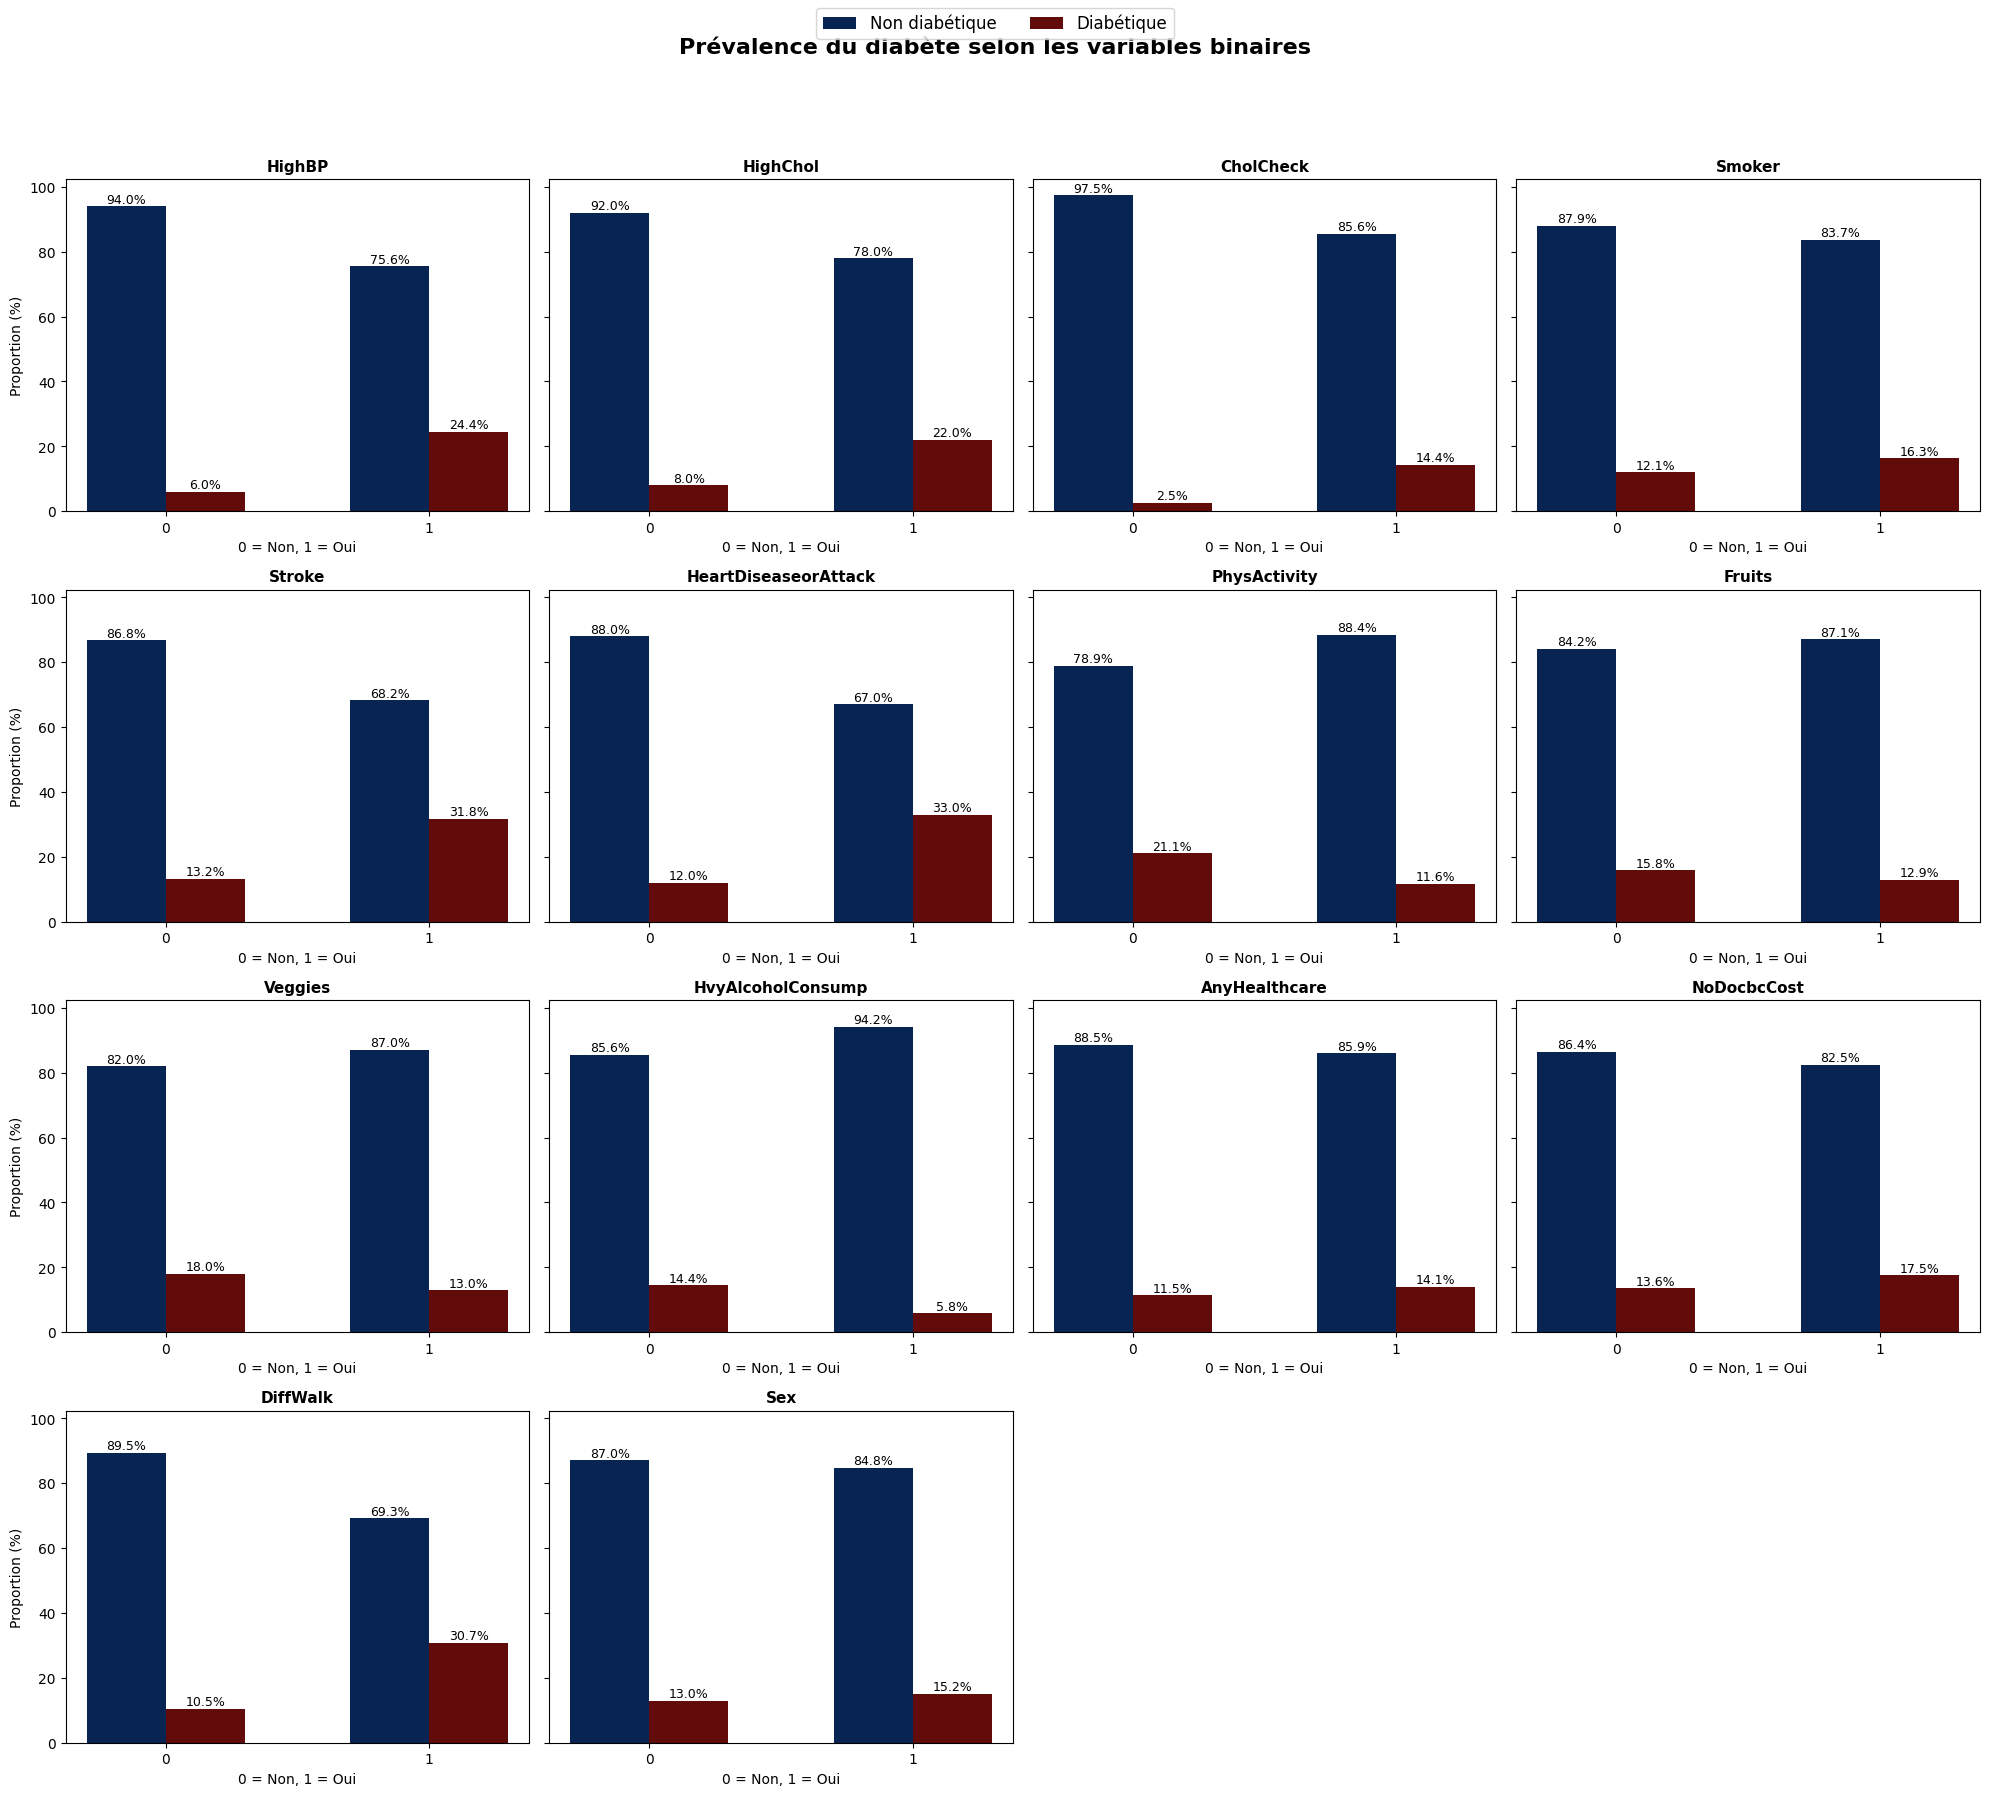

In [57]:
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

n_vars = len(binary)
n_cols = 4
n_rows = math.ceil(n_vars / n_cols)

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(20, 4.5 * n_rows),
    sharey=True
)

axes = axes.flatten()

bar_width = 0.30          # ← largeur des barres (plus petit = plus fin)
x = np.arange(2)          # positions 0 et 1

for i, var in enumerate(binary):
    crosstab_pct = pd.crosstab(
        df[var],
        df["Diabetes_binary"],
        normalize="index"
    ) * 100

    ax = axes[i]

    # Barres rapprochées
    ax.bar(x - bar_width/2, crosstab_pct[0], width=bar_width,
           color="#072452", label="Non diabétique")
    ax.bar(x + bar_width/2, crosstab_pct[1], width=bar_width,
           color="#610B0B", label="Diabétique")

    # Ajout des pourcentages
    for j in range(2):
        ax.text(x[j] - bar_width/2, crosstab_pct.iloc[j, 0] + 1,
                f"{crosstab_pct.iloc[j, 0]:.1f}%", ha='center', fontsize=9)
        ax.text(x[j] + bar_width/2, crosstab_pct.iloc[j, 1] + 1,
                f"{crosstab_pct.iloc[j, 1]:.1f}%", ha='center', fontsize=9)

    ax.set_title(var, fontsize=11, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(["0", "1"])
    ax.set_xlabel("0 = Non, 1 = Oui")

    if i % n_cols == 0:
        ax.set_ylabel("Proportion (%)")

# Supprimer les axes inutilisés
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Légende globale
fig.legend(
    ["Non diabétique", "Diabétique"],
    loc="upper center",
    ncol=2,
    fontsize=12
)

fig.suptitle(
    "Prévalence du diabète selon les variables binaires",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()


### Résultats – variables binaires

L’analyse descriptive met en évidence des **différences marquées de prévalence du diabète** selon plusieurs variables binaires liées à l’état de santé, aux comportements et aux conditions de vie des individus. Les **facteurs médicaux** apparaissent comme les plus fortement associés au diabète : l’hypertension artérielle, l’hypercholestérolémie, les antécédents cardiovasculaires et les difficultés de mobilité sont systématiquement associés à une prévalence nettement plus élevée du diabète.

Les **comportements de santé** montrent des résultats cohérents avec la littérature. L’activité physique régulière, ainsi que la consommation quotidienne de fruits et de légumes, sont associées à une prévalence plus faible du diabète, bien que ces effets restent modérés par rapport aux facteurs médicaux majeurs et puissent refléter un **mode de vie globalement plus sain**.

L’effet du tabagisme apparaît limité. En revanche, la **consommation excessive d’alcool** présente une association contre-intuitive avec une prévalence plus faible du diabète. Ce résultat ne doit pas être interprété de manière causale et s’explique vraisemblablement par des mécanismes de **causalité inversée**, des **effets de sélection** et un possible **effet de substitution entre alcool et boissons sucrées**, la consommation de sucre n’étant pas observée dans les données.

Les variables liées à l’**accès aux soins** indiquent qu’un meilleur suivi médical (tests de cholestérol) est associé à une prévalence plus élevée du diabète, tandis que les contraintes financières d’accès aux soins sont associées à une prévalence plus élevée, suggérant un **retard de diagnostic ou de prise en charge**. Enfin, les différences selon le sexe restent **modestes** comparées aux autres facteurs étudiés.


C:\Users\nouts\AppData\Local\Temp\ipykernel_37304\3283308253.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\nouts\AppData\Local\Temp\ipykernel_37304\3283308253.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\nouts\AppData\Local\Temp\ipykernel_37304\3283308253.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\nouts\AppData\Local\Temp\ipykernel_37304\3283308253.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` varia

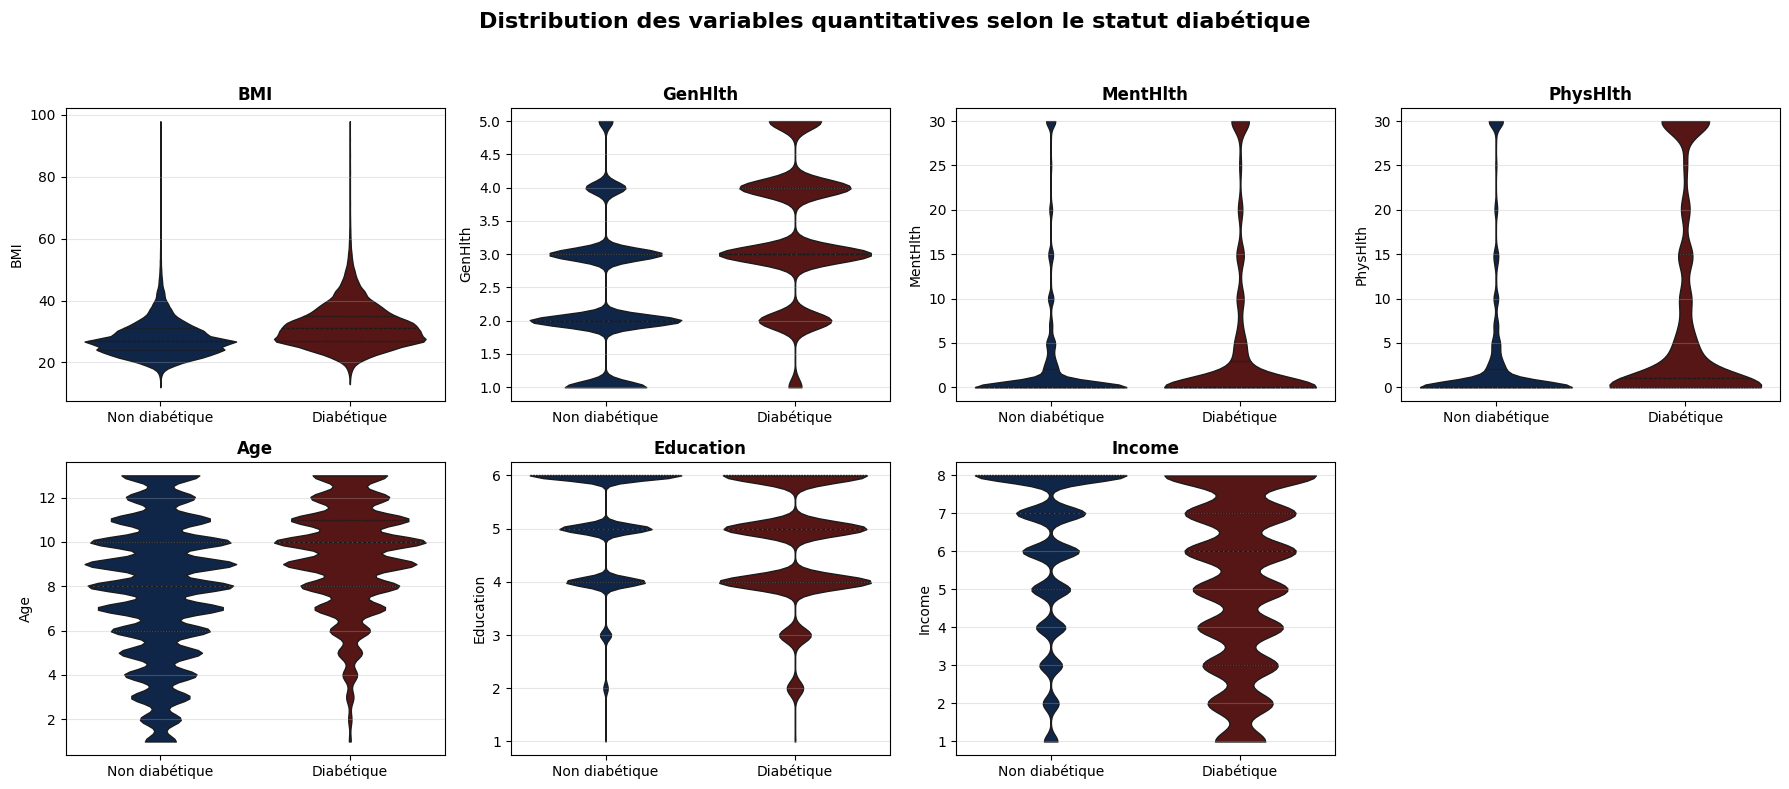

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

quant_vars = ["BMI", "GenHlth", "MentHlth", "PhysHlth", "Age", "Education", "Income"]

n_cols = 4
n_rows = int(np.ceil(len(quant_vars) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 8))
axes = axes.flatten()

for i, var in enumerate(quant_vars):
    sns.violinplot(
        data=df,
        x="Diabetes_binary",
        y=var,
        inner="quartile",
        cut=0,
        linewidth=1,
        palette=["#072452", "#610B0B"],
        ax=axes[i]
    )
    axes[i].set_title(var, fontsize=12, fontweight="bold")
    axes[i].set_xlabel("")
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(["Non diabétique", "Diabétique"])
    axes[i].grid(axis="y", alpha=0.3)

# Supprimer les axes vides
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(
    "Distribution des variables quantitatives selon le statut diabétique",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [59]:
# Moyennes par statut diabétique
means = df.groupby("Diabetes_binary")[quant_vars].mean()

# Différence et ratio
comparison = pd.DataFrame({
    "Mean (Non diabétique)": means.loc[0],
    "Mean (Diabétique)": means.loc[1],
    "Difference (Diabétique - Non)": means.loc[1] - means.loc[0],
    "Ratio (Diabétique / Non)": means.loc[1] / means.loc[0]
})

# Arrondir pour lisibilité
comparison = comparison.round(2)

display(comparison)


,Mean (Non diabétique),Mean (Diabétique),Difference (Diabétique - Non),Ratio (Diabétique / Non)
BMI,27.81,31.94,4.14,1.15
GenHlth,2.39,3.29,0.91,1.38
MentHlth,2.98,4.46,1.48,1.50
PhysHlth,3.64,7.95,4.31,2.18
Age,7.81,9.38,1.56,1.20
Education,5.10,4.75,-0.35,0.93
Income,6.19,5.21,-0.98,0.84


### Résultats – variables quantitatives et catégorielles ordonnées

L’analyse des distributions met en évidence des **différences nettes et cohérentes** entre les individus diabétiques et non diabétiques pour plusieurs variables quantitatives. Les écarts les plus marqués concernent le **BMI**, l’**âge**, l’**état de santé général** et la **santé physique**. Les individus diabétiques présentent en moyenne un BMI plus élevé, appartiennent plus fréquemment à des tranches d’âge supérieures et déclarent un état de santé général plus dégradé, ainsi qu’un nombre plus important de jours de mauvaise santé physique.

Les variables de **santé mentale** montrent des différences plus modérées, bien que les diabétiques présentent une dispersion plus importante et des valeurs extrêmes plus fréquentes. Les variables **socio-économiques**, telles que le niveau d’éducation et le revenu, indiquent également un gradient en défaveur des individus diabétiques, mais avec un chevauchement important entre les distributions, suggérant un **effet indirect** plutôt qu’un facteur déterminant isolé.

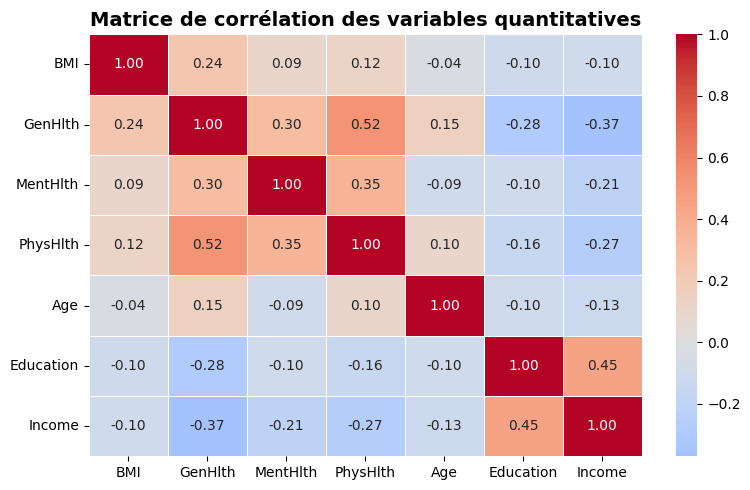

In [63]:
# Matrice de corrélation (Pearson)
corr_matrix = df[quant_vars].corr()

# Heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Matrice de corrélation des variables quantitatives", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


La matrice de corrélation révèle des relations modérées et cohérentes entre les variables de santé, ainsi qu’un gradient socio-économique marqué, sans mettre en évidence de multicolinéarité sévère. Ces résultats confirment la pertinence de l’ensemble des variables pour une modélisation multivariée du diabète.


### Représentation des variables continues de la base

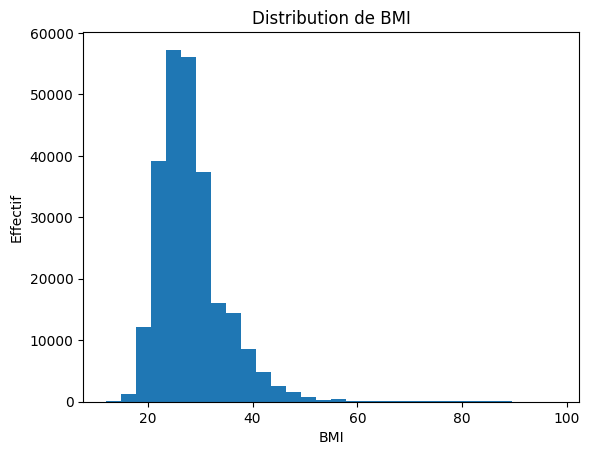

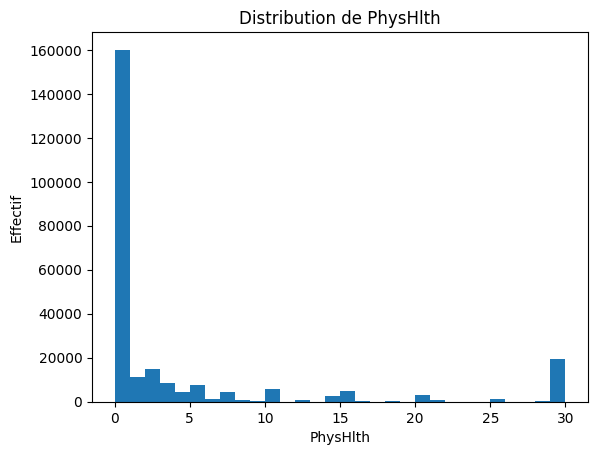

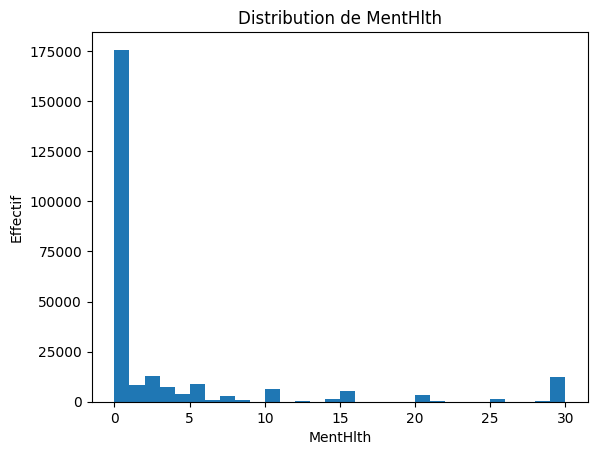

In [60]:

vars_to_plot = ["BMI", "PhysHlth", "MentHlth"]

for col in vars_to_plot:
    plt.figure()
    plt.hist(X[col].dropna(), bins=30)
    plt.title(f"Distribution de {col}")
    plt.xlabel(col)
    plt.ylabel("Effectif")
    plt.show()


## ML MODELS


### Splitting and scaling

In [19]:
## Train-test split avec stratification

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    shuffle=True,     
    stratify=y
)

## Preprocessing: scale ONLY numeric columns (fit on TRAIN via Pipeline)
candidate_numeric = ["BMI", "PhysHlth", "MentHlth"]
numeric_cols = [c for c in candidate_numeric if c in X_train.columns]

if len(numeric_cols) == 0:
    raise ValueError("None of ['BMI','PhysHlth','MentHlth'] found in the dataset columns.")

preprocess_scale_some = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols)
    ],
    remainder="passthrough"
)

preprocess_no_scale = "passthrough"

In [20]:
## Define Pipelines (scaling depends on model)

pipelines = {
    # Models sensitive to scaling -> use preprocess_scale_some
    "LogisticRegression": Pipeline(steps=[
        ("preprocess", preprocess_scale_some),
        ("model", LogisticRegression(
            max_iter=2000,
            solver="lbfgs",
            class_weight="balanced"  # handles imbalance internally
        ))
    ]),
    "MLP": Pipeline(steps=[
        ("preprocess", preprocess_scale_some),
        ("model", MLPClassifier(
            hidden_layer_sizes=(64, 32),
            max_iter=500,
            random_state=42
        ))
    ]),

    # Tree-based models -> no scaling needed
    "RandomForest": Pipeline(steps=[
        ("preprocess", preprocess_no_scale),
        ("model", RandomForestClassifier(
            n_estimators=400,
            random_state=42,
            n_jobs=-1,
            class_weight="balanced"  # handles imbalance internally
        ))
    ]),
    "GradientBoosting": Pipeline(steps=[
        ("preprocess", preprocess_no_scale),
        ("model", GradientBoostingClassifier(random_state=42))
    ]),
}


# Models that do NOT support class_weight -> pass sample_weight at fit-time
needs_sample_weight = {"GradientBoosting", "MLP"}

# Precompute sample weights for training labels only (no leakage)
sample_weight_train = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

In [21]:
# 6) Train + Evaluate
# -------------------------------------------------------------------
def evaluate(name, pipe):
    # Fit with proper weighting
    if name in needs_sample_weight:
        pipe.fit(X_train, y_train, model__sample_weight=sample_weight_train)
    else:
        pipe.fit(X_train, y_train)

    # Predictions
    y_pred = pipe.predict(X_test)

    # Probabilities for AUC metrics if available
    y_proba = None
    model = pipe.named_steps["model"]
    if hasattr(model, "predict_proba"):
        y_proba = pipe.predict_proba(X_test)[:, 1]

    print("\n" + "=" * 80)
    print(f"MODEL: {name}")
    print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
    print("\nClassification report:\n", classification_report(y_test, y_pred, digits=4, zero_division=0))

    if y_proba is not None:
        print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")
        print(f"PR-AUC : {average_precision_score(y_test, y_proba):.4f}")

    return pipe

trained_pipes = {}
for name, pipe in pipelines.items():
    trained_pipes[name] = evaluate(name, pipe)

C:\Users\nouts\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)



MODEL: LogisticRegression
Confusion matrix:
 [[31737 11930]
 [ 1691  5378]]

Classification report:
               precision    recall  f1-score   support

           0     0.9494    0.7268    0.8233     43667
           1     0.3107    0.7608    0.4412      7069

    accuracy                         0.7315     50736
   macro avg     0.6301    0.7438    0.6323     50736
weighted avg     0.8604    0.7315    0.7701     50736

ROC-AUC: 0.8196
PR-AUC : 0.3926


TypeError: BaseMultilayerPerceptron.fit() got an unexpected keyword argument 'sample_weight'